In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import ruptures as rpt

plt.style.use("ggplot")

In [8]:
prices = pd.read_csv("../Data/BrentOilPrices.csv")

prices["Date"] = pd.to_datetime(prices["Date"])

prices.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [10]:
events = pd.read_csv("../Data/oil_market_events.csv")

events["start_date"] = pd.to_datetime(events["start_date"])
events["end_date"] = pd.to_datetime(events["end_date"])

events.head()

,event_id,start_date,end_date,event_name,category,description,expected_direction
0,1,1990-08-02,1991-02-28,Iraq invasion of Kuwait / Gulf War,Geopolitical conflict,Iraq's invasion of Kuwait removed a large shar...,Increase then reversal
1,2,1997-07-02,1998-12-31,Asian Financial Crisis and 1998 price collapse,Economic shock,The Thai baht devaluation triggered a wider As...,Decrease
2,3,2001-09-11,2001-10-31,September 11 terrorist attacks,Geopolitical shock,The attacks on the United States created short...,Decrease
3,4,2003-03-20,2003-05-01,US-led invasion of Iraq,Geopolitical conflict,The invasion raised concerns about Middle East...,Increase
4,5,2005-08-29,2005-10-15,Hurricane Katrina,Supply disruption,Hurricane Katrina and the following Hurricane ...,Increase


In [11]:
prices = prices.sort_values("Date")

prices.reset_index(drop=True, inplace=True)

signal = prices["Price"].values

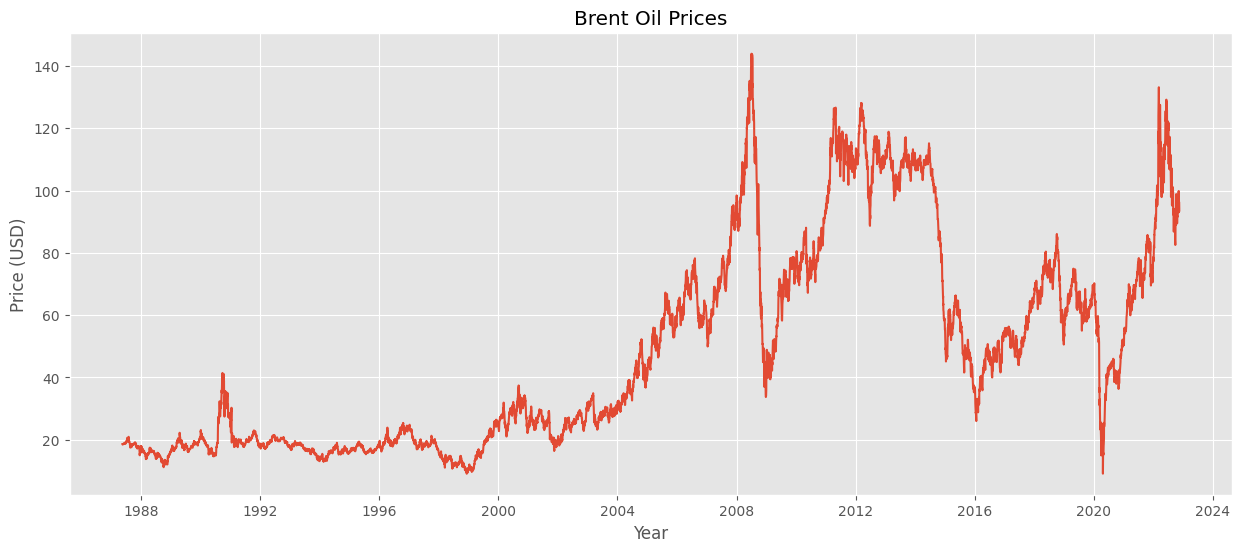

In [12]:
plt.figure(figsize=(15,6))

plt.plot(prices["Date"], prices["Price"])

plt.title("Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Price (USD)")

plt.show()

In [13]:
model = rpt.Pelt(model="rbf")

result = model.fit(signal).predict(pen=10)

result

[820,
 935,
 2695,
 3100,
 4220,
 4370,
 4600,
 5090,
 5200,
 5315,
 5415,
 5445,
 5595,
 5695,
 5980,
 6035,
 6340,
 6925,
 6985,
 7155,
 7350,
 7700,
 7840,
 7990,
 8330,
 8380,
 8540,
 8640,
 8815,
 8940,
 9011]

In [14]:
change_dates = []

for cp in result[:-1]:      # Ignore last endpoint

    change_dates.append(prices.iloc[cp]["Date"])

change_dates

[Timestamp('1990-08-06 00:00:00'),
 Timestamp('1991-01-16 00:00:00'),
 Timestamp('1997-12-29 00:00:00'),
 Timestamp('1999-08-09 00:00:00'),
 Timestamp('2003-12-29 00:00:00'),
 Timestamp('2004-07-27 00:00:00'),
 Timestamp('2005-06-16 00:00:00'),
 Timestamp('2007-05-18 00:00:00'),
 Timestamp('2007-10-24 00:00:00'),
 Timestamp('2008-04-11 00:00:00'),
 Timestamp('2008-09-03 00:00:00'),
 Timestamp('2008-10-15 00:00:00'),
 Timestamp('2009-05-21 00:00:00'),
 Timestamp('2009-10-13 00:00:00'),
 Timestamp('2010-11-30 00:00:00'),
 Timestamp('2011-02-17 00:00:00'),
 Timestamp('2012-05-15 00:00:00'),
 Timestamp('2014-09-08 00:00:00'),
 Timestamp('2014-12-02 00:00:00'),
 Timestamp('2015-08-04 00:00:00'),
 Timestamp('2016-05-10 00:00:00'),
 Timestamp('2017-09-19 00:00:00'),
 Timestamp('2018-04-10 00:00:00'),
 Timestamp('2018-11-08 00:00:00'),
 Timestamp('2020-03-09 00:00:00'),
 Timestamp('2020-05-21 00:00:00'),
 Timestamp('2021-01-06 00:00:00'),
 Timestamp('2021-06-01 00:00:00'),
 Timestamp('2022-02-

In [15]:
cp_df = pd.DataFrame({
    "Change Point": change_dates
})

cp_df

,Change Point
0,1990-08-06
1,1991-01-16
2,1997-12-29
3,1999-08-09
4,2003-12-29
5,2004-07-27
6,2005-06-16
7,2007-05-18
8,2007-10-24
9,2008-04-11


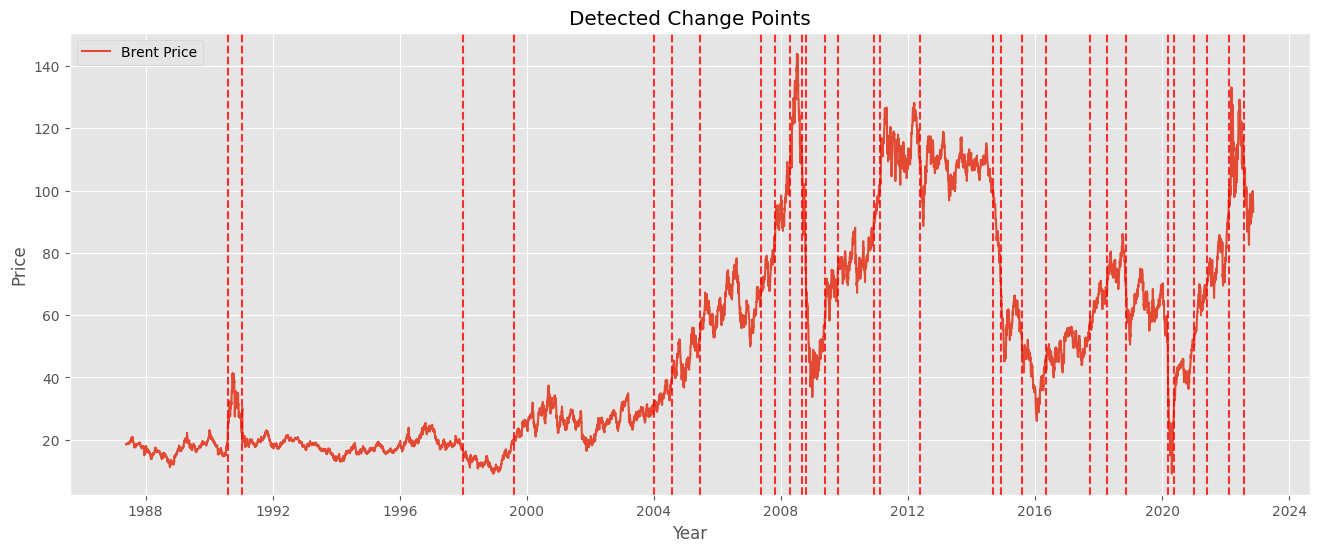

In [16]:
plt.figure(figsize=(16,6))

plt.plot(prices["Date"],
         prices["Price"],
         label="Brent Price")

for cp in change_dates:

    plt.axvline(cp,
                color="red",
                linestyle="--",
                alpha=0.8)

plt.title("Detected Change Points")

plt.xlabel("Year")

plt.ylabel("Price")

plt.legend()

plt.show()

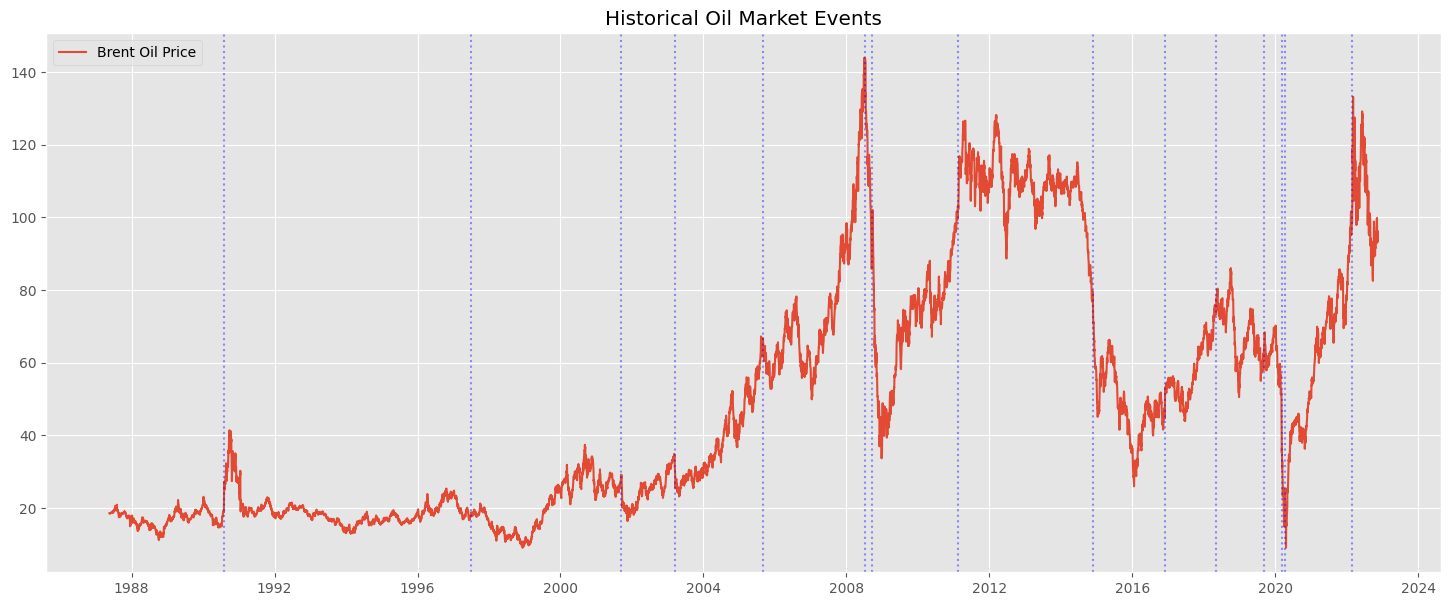

In [19]:
plt.figure(figsize=(18,7))

plt.plot(prices["Date"],
         prices["Price"],
         label="Brent Oil Price")

for _, row in events.iterrows():

    plt.axvline(
        row["start_date"],
        color="blue",
        alpha=0.4,
        linestyle=":"
    )

plt.title("Historical Oil Market Events")

plt.legend()

plt.show()

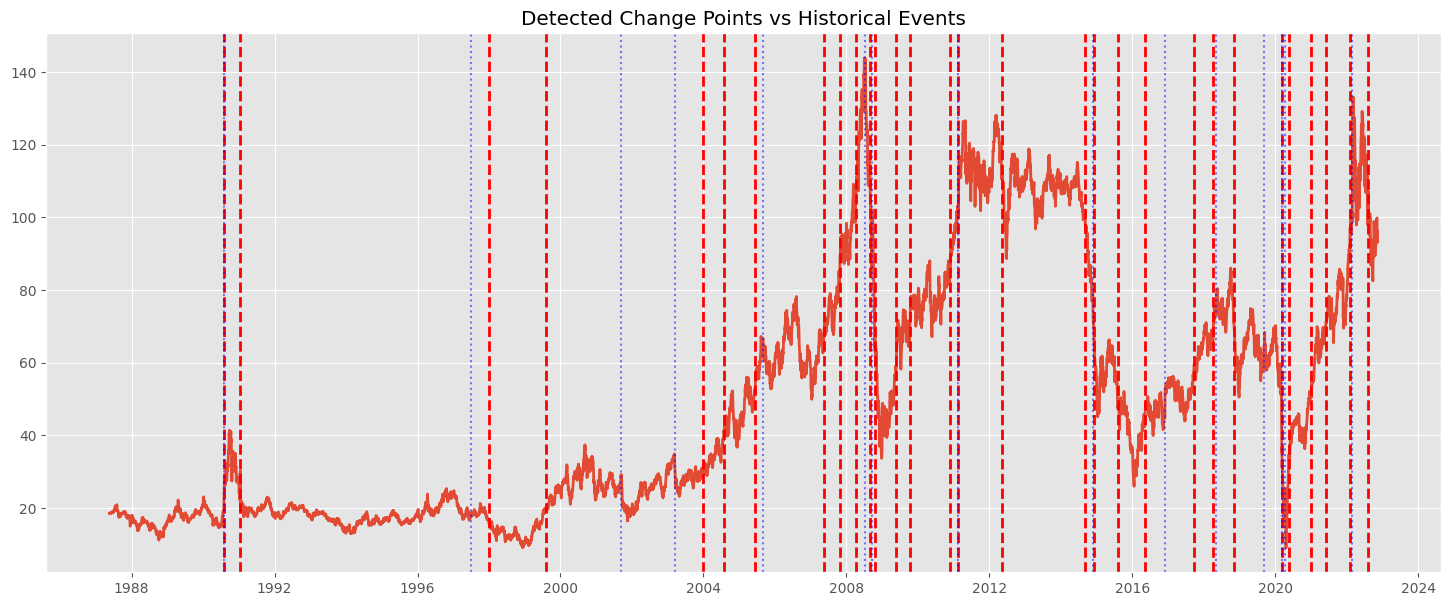

In [21]:
plt.figure(figsize=(18,7))

plt.plot(prices["Date"],
         prices["Price"],
         linewidth=2,
         label="Brent Price")

# Change points
for cp in change_dates:

    plt.axvline(cp,
                color="red",
                linestyle="--",
                linewidth=2)

# Historical events
for _, row in events.iterrows():

    plt.axvline(
        row["start_date"],
        color="blue",
        alpha=0.5,
        linestyle=":"
    )

plt.title("Detected Change Points vs Historical Events")

plt.show()

In [24]:
comparison = []

for cp in change_dates:

    # Find the nearest historical event
    nearest = events.iloc[
        (events["start_date"] - cp).abs().argsort()[:1]
    ]

    comparison.append({
        "Detected Change Point": cp.date(),
        "Nearest Event": nearest.iloc[0]["event_name"],
        "Event Start Date": nearest.iloc[0]["start_date"].date(),
        "Category": nearest.iloc[0]["category"],
        "Expected Direction": nearest.iloc[0]["expected_direction"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Detected Change Point,Nearest Event,Event Start Date,Category,Expected Direction
0,1990-08-06,Iraq invasion of Kuwait / Gulf War,1990-08-02,Geopolitical conflict,Increase then reversal
1,1991-01-16,Iraq invasion of Kuwait / Gulf War,1990-08-02,Geopolitical conflict,Increase then reversal
2,1997-12-29,Asian Financial Crisis and 1998 price collapse,1997-07-02,Economic shock,Decrease
3,1999-08-09,September 11 terrorist attacks,2001-09-11,Geopolitical shock,Decrease
4,2003-12-29,US-led invasion of Iraq,2003-03-20,Geopolitical conflict,Increase
5,2004-07-27,Hurricane Katrina,2005-08-29,Supply disruption,Increase
6,2005-06-16,Hurricane Katrina,2005-08-29,Supply disruption,Increase
7,2007-05-18,Brent record peak (~USD 147/bbl),2008-07-11,Market/demand cycle,Peak
8,2007-10-24,Brent record peak (~USD 147/bbl),2008-07-11,Market/demand cycle,Peak
9,2008-04-11,Brent record peak (~USD 147/bbl),2008-07-11,Market/demand cycle,Peak
